# Dataset description
## Gender share population per age group

**Source**: Dane Censo Nacional de poblacion y vivienda 2018

**Download**: [link](https://www.dane.gov.co/index.php/estadisticas-por-tema/demografia-y-poblacion/proyecciones-de-poblacion)

# Code
## Imports

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text

## Load data

In [7]:
path = "data/nacional.csv"

df = pd.read_csv(path, encoding="utf-8")

## Clean data

In [8]:
columns = df.columns[~(df.columns.str.contains("Total"))]
df_f = df.loc[:, columns]

PYRAMID_GROUPS = [(f"{lo}–{lo + 4}", lo, lo + 4) for lo in range(0, 100, 5)] + [("100+", 100, 100)]

def pyramid_rows(df: pd.DataFrame, year: int) -> tuple:
    df_local = df.copy()
    df_local = df_local[df_local["AÑO"].eq(year)]

    men, women = {}, {}
    for label, lo, hi in PYRAMID_GROUPS:
        hcols = [f"Hombres_{n}" for n in range(lo, hi + 1) if f"Hombres_{n}" in df_local.columns]
        mcols = [f"Mujeres_{n}" for n in range(lo, hi + 1) if f"Mujeres_{n}" in df_local.columns]
        men[label] = float(df_local[hcols].to_numpy().sum())
        women[label] = float(df_local[mcols].to_numpy().sum())

    men, women = pd.Series(men, name="Men"), pd.Series(women, name="Women")

    bucket = (men + women).replace(0, 1) 
    men, women = men / bucket * 100, women / bucket * 100

    return men, women

men, women = pyramid_rows(df_f, 2026)

## Plot

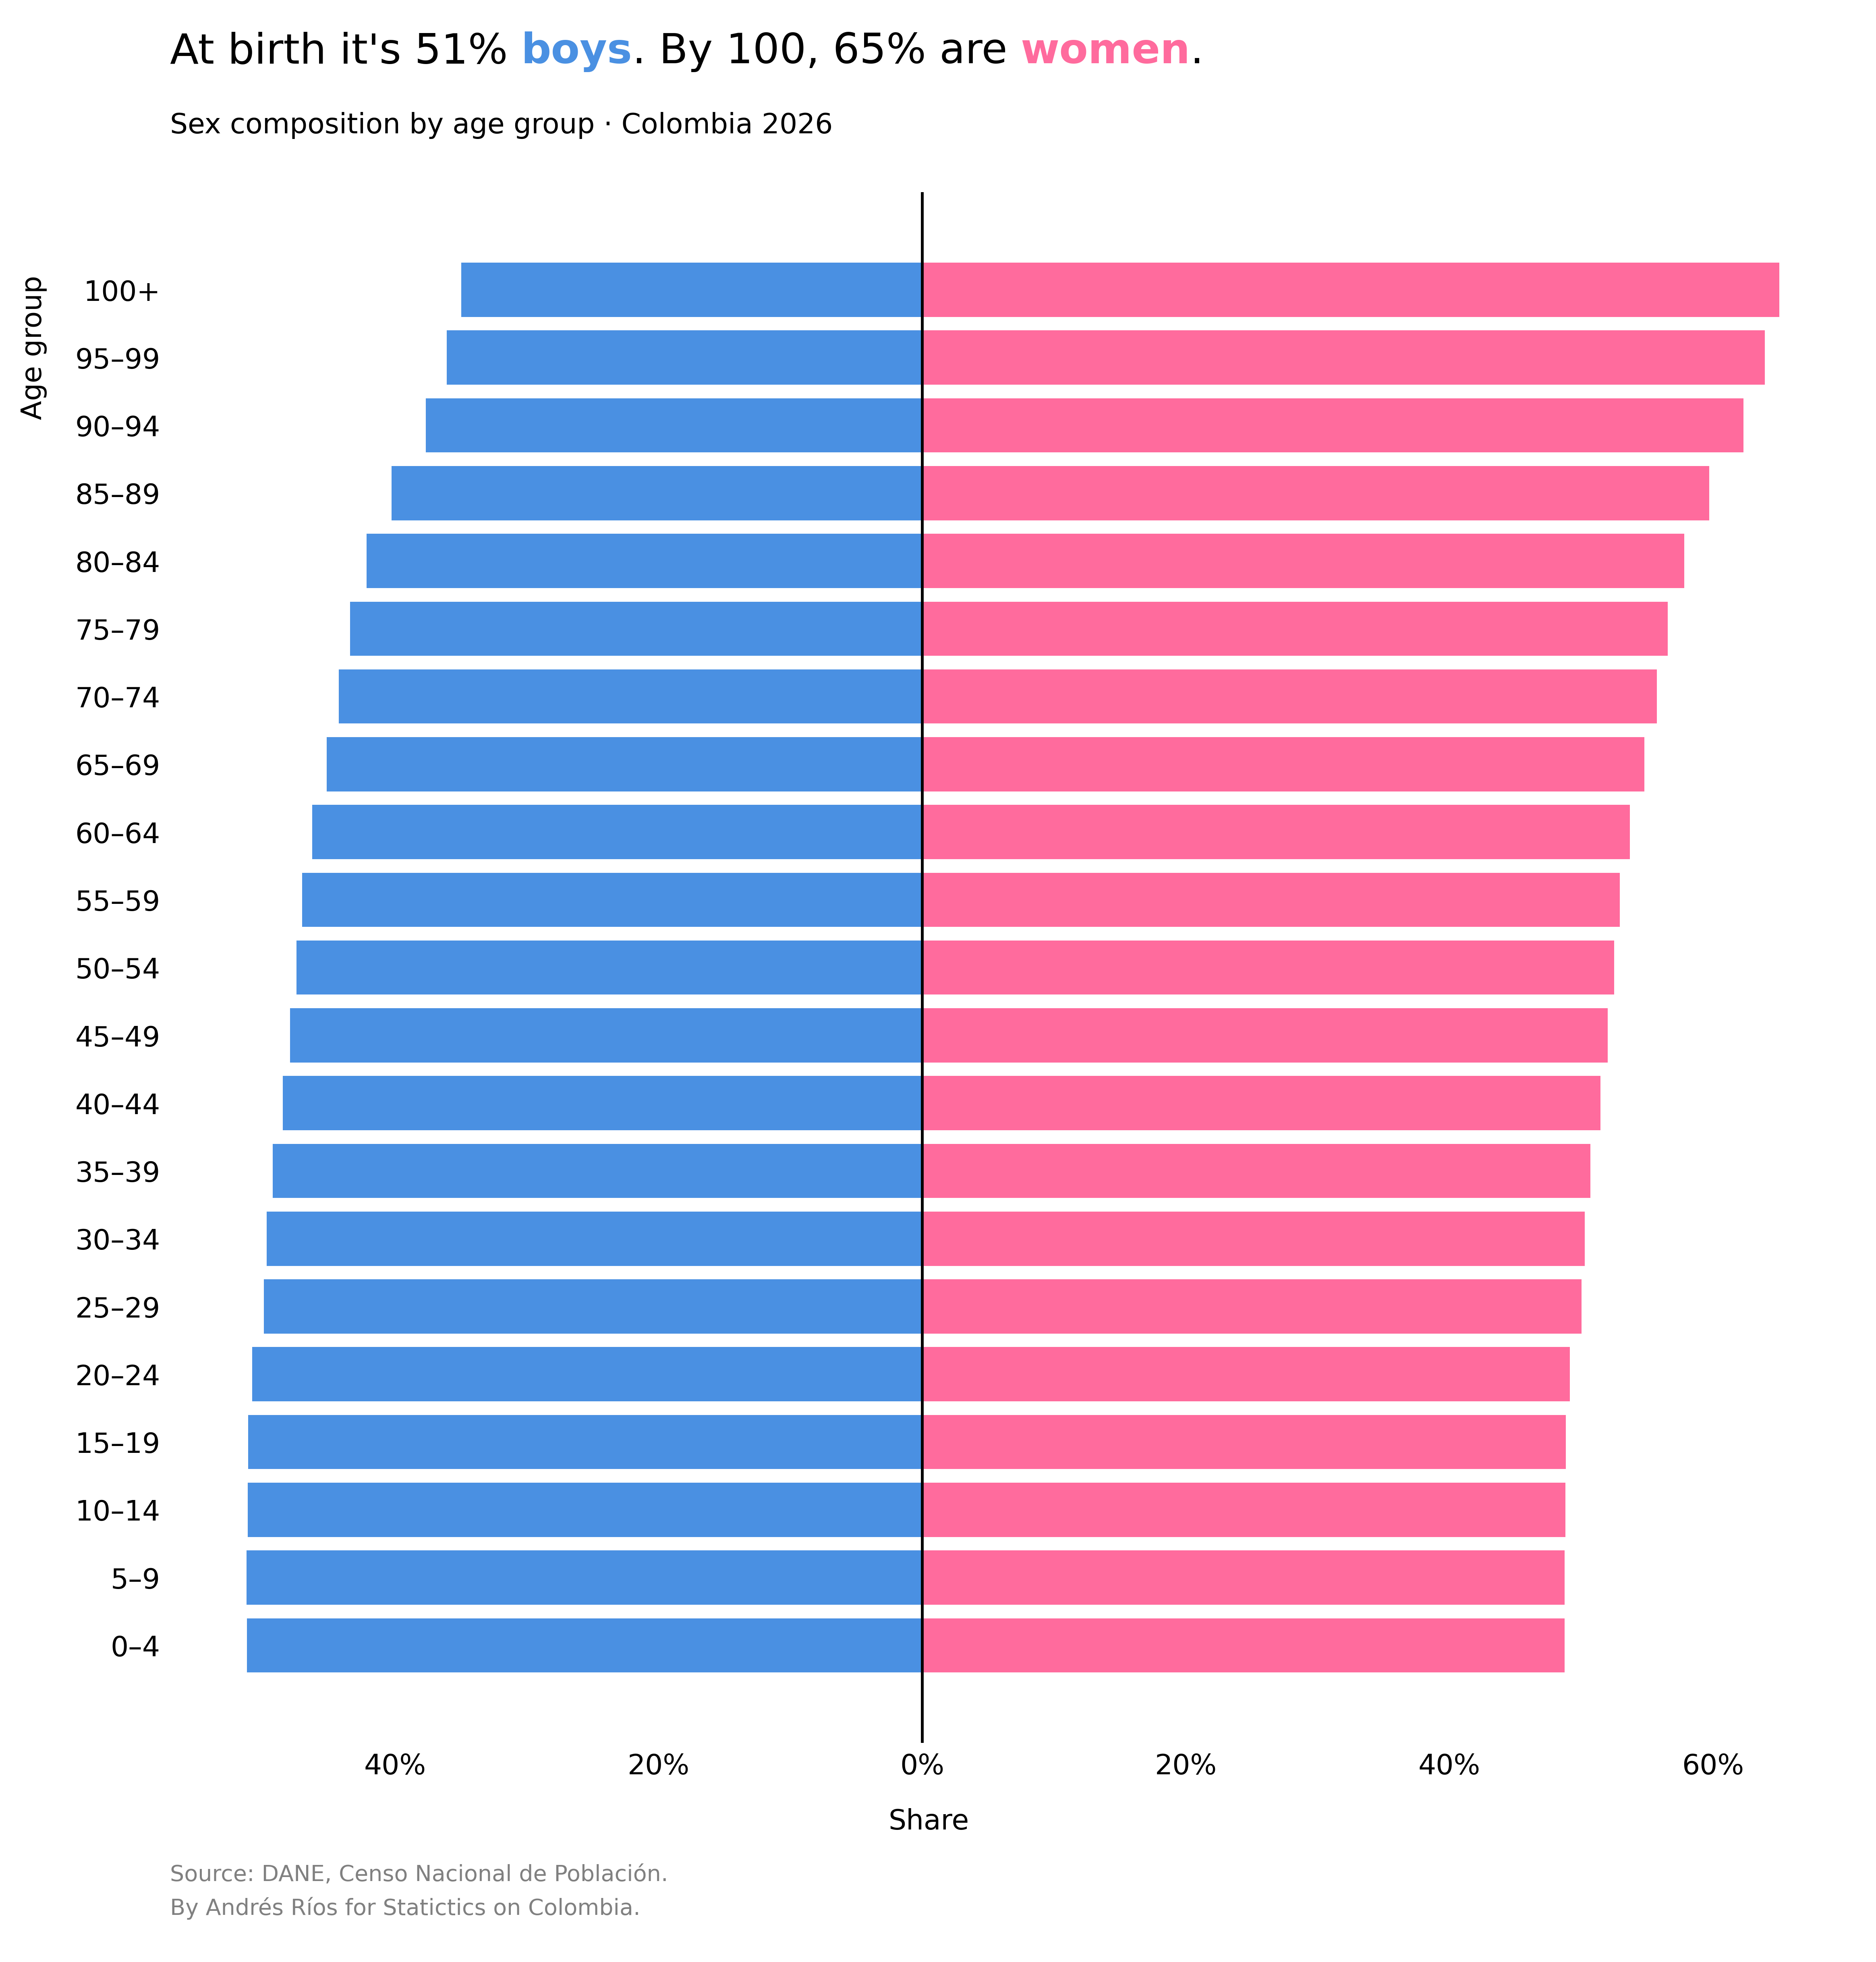

In [9]:
women_color = "#FF6B9D"
men_color = "#4A90E2"
ages = men.index

plt.figure(figsize=(10.8, 10), dpi=500)

plt.barh(ages, [-x for x in men], color=men_color)
plt.barh(ages, women, color=women_color)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{abs(x):.0f}%"))

plt.axvline(x=0, color="black", linewidth=1)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.ylabel("Age group", labelpad=10, fontsize=10, y=0.9)
plt.xlabel("Share", labelpad=10, fontsize=10, x=0.45)

fig_text(
 0.125, 0.96,
 s="At birth it's 51% <boys>. By 100, 65% are <women>.",
 highlight_textprops=[
        {"color": men_color, "weight": "bold"},
        {"color": women_color, "weight": "bold"}
    ],
 fontsize=15,
)

fig_text(
 0.125, 0.92,
 s="Sex composition by age group · Colombia 2026",
 fontsize=10,
)

fig_text(
 0.125, 0.05, 
 "Source: DANE, Censo Nacional de Población.\n"
 "By Andrés Ríos for Statictics on Colombia.\n", 
 fontsize=8, color="gray",
)

plt.show()